In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


hr_df = pd.read_csv(
    "../data/heart_rate_7users_daily_avgHR_CLEAN_v2.csv"
)

steps_df = pd.read_csv(
    "../data/steps_7users_overtrained_full.csv"
)

hr_df["calendar_date"] = pd.to_datetime(hr_df["calendar_date"])
steps_df["calendar_date"] = pd.to_datetime(steps_df["calendar_date"])

print(f"Heart Rate DataFrame shape: {hr_df.shape}")
print(f"Steps DataFrame shape: {steps_df.shape}")

merged_df = pd.merge(
    hr_df,
    steps_df,
    on=["sdv_user_id", "calendar_date"],
    how="inner"
)

merged_df = merged_df[[
    "sdv_user_id",
    "calendar_date",
    "heart_rate_per_point",
    "average_stress_level",
    "steps"
]]

print(merged_df.head())



Heart Rate DataFrame shape: (2555, 12)
Steps DataFrame shape: (2555, 11)
   sdv_user_id calendar_date  heart_rate_per_point  average_stress_level  \
0         8101    2025-01-01              115.0125                  26.0   
1         8101    2025-02-01              140.0000                  37.0   
2         8101    2025-03-01              120.7025                  30.0   
3         8101    2025-04-01              123.1575                  32.0   
4         8101    2025-05-01              125.8775                  25.0   

   steps  
0   9245  
1  19145  
2  11281  
3  12143  
4  13651  


In [3]:
hr_df = hr_df.sort_values(["sdv_user_id", "calendar_date"])

hr_df["hr_7d_avg"] = (
    hr_df
    .groupby("sdv_user_id")["heart_rate_per_point"]
    .rolling(window=7)
    .mean()
    .reset_index(level=0, drop=True)
)

hr_df["stress_7d_avg"] = (
    hr_df
    .groupby("sdv_user_id")["average_stress_level"]
    .rolling(window=7)
    .mean()
    .reset_index(level=0, drop=True)
)


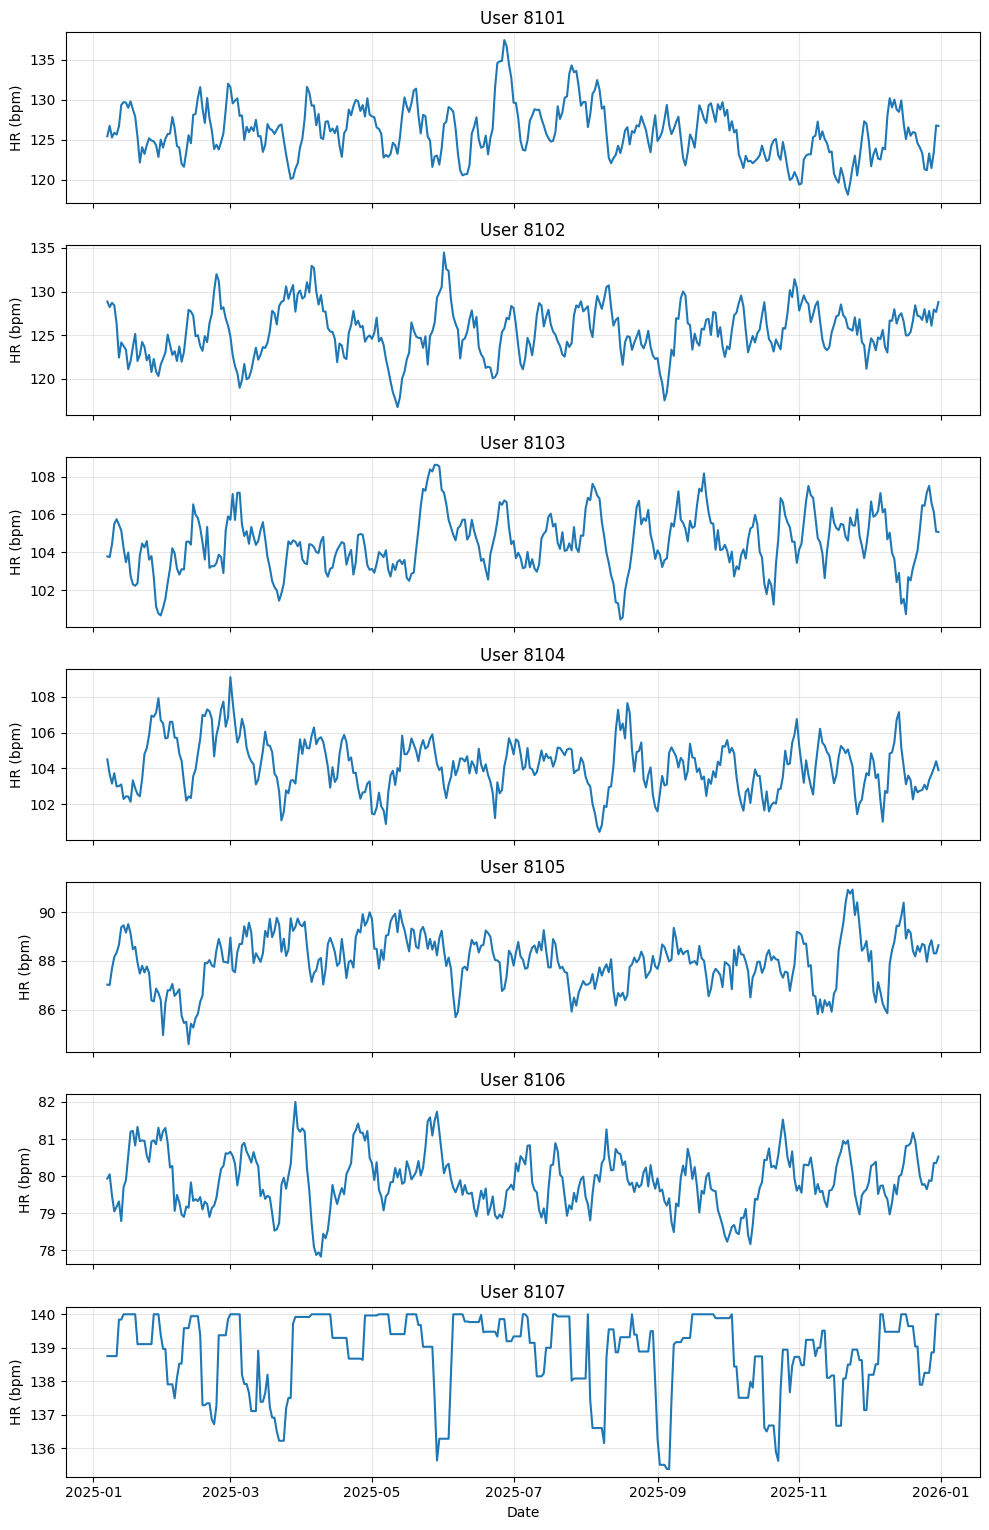

In [4]:
users = hr_df["sdv_user_id"].unique()

fig, axes = plt.subplots(
    nrows=len(users),
    ncols=1,
    figsize=(10, 2.2 * len(users)),
    sharex=True
)

for ax, user in zip(axes, users):
    user_data = hr_df[hr_df["sdv_user_id"] == user]

    ax.plot(
        user_data["calendar_date"],
        user_data["hr_7d_avg"]
    )

    ax.set_title(f"User {user}")
    ax.set_ylabel("HR (bpm)")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


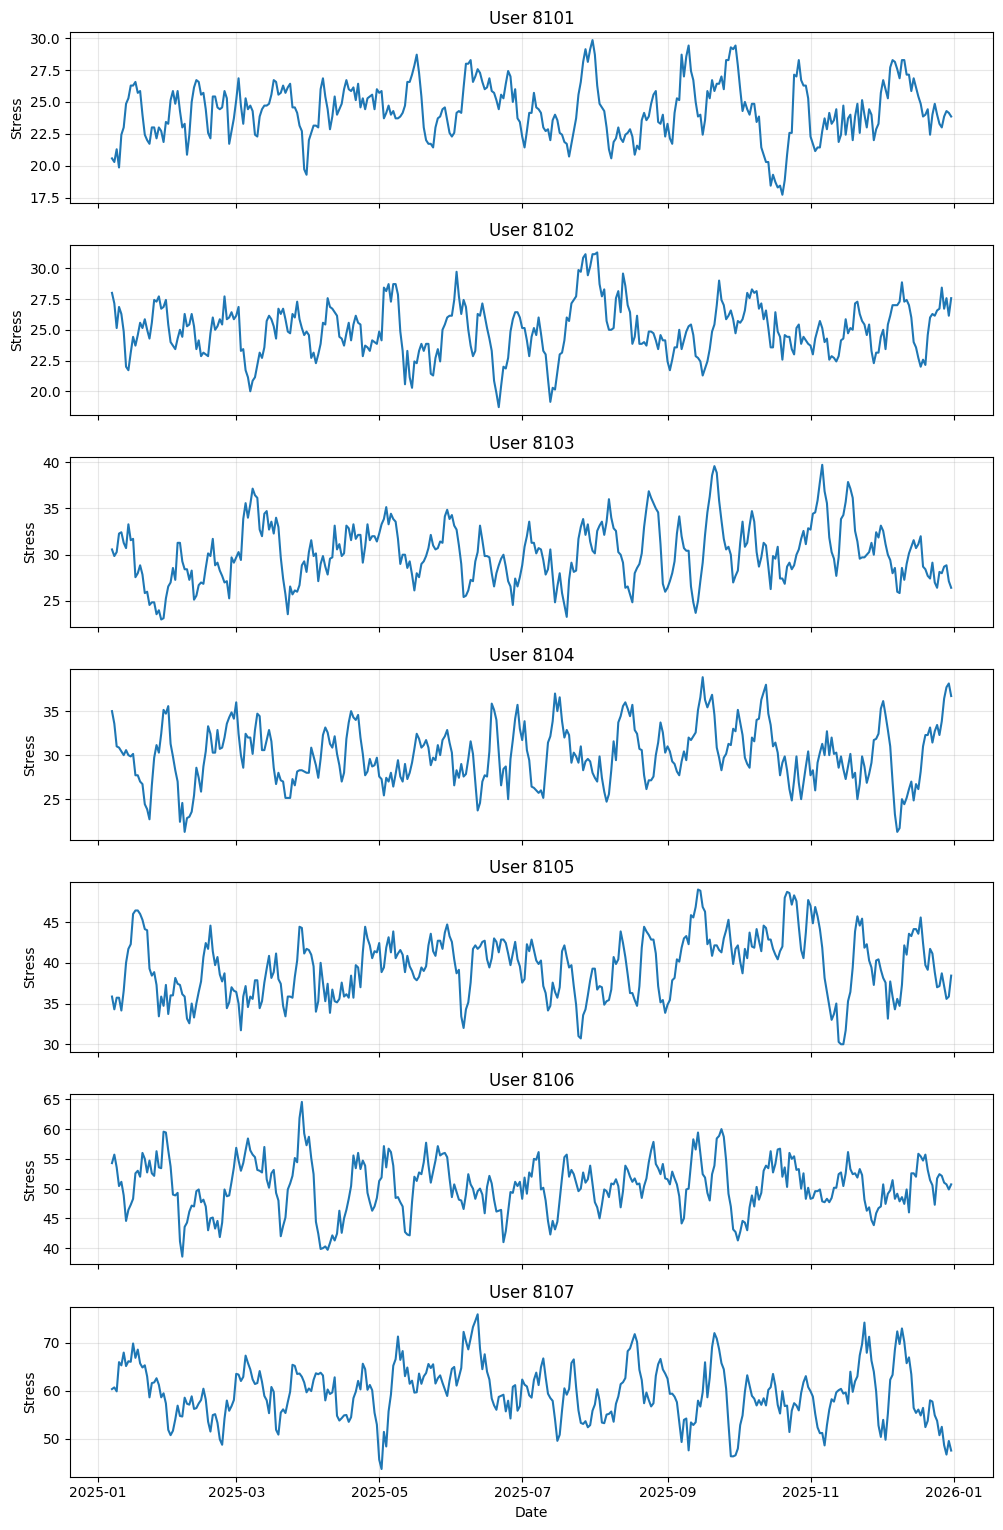

In [5]:
fig, axes = plt.subplots(
    nrows=len(users),
    ncols=1,
    figsize=(10, 2.2 * len(users)),
    sharex=True
)

for ax, user in zip(axes, users):
    user_data = hr_df[hr_df["sdv_user_id"] == user]

    ax.plot(
        user_data["calendar_date"],
        user_data["stress_7d_avg"]
    )

    ax.set_title(f"User {user}")
    ax.set_ylabel("Stress")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


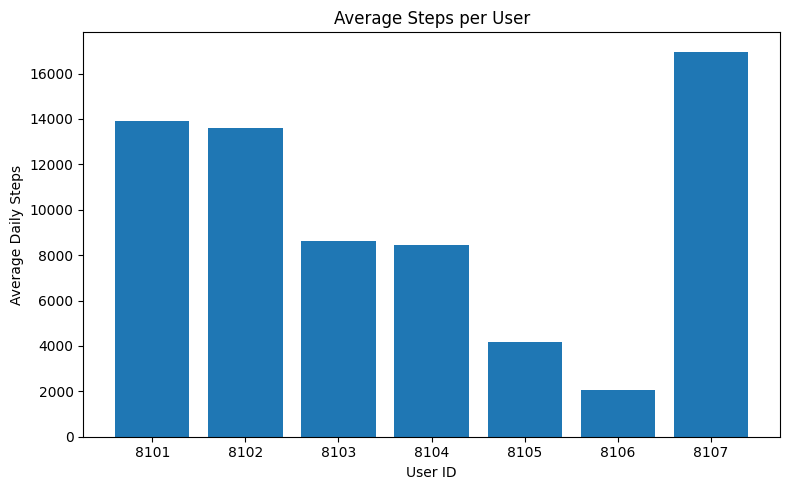

In [6]:
avg_steps_per_user = (
    steps_df
    .groupby("sdv_user_id")["steps"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.bar(
    avg_steps_per_user["sdv_user_id"],
    avg_steps_per_user["steps"]
)

plt.title("Average Steps per User")
plt.xlabel("User ID")
plt.ylabel("Average Daily Steps")
plt.tight_layout()
plt.show()


In [12]:
analysis_df = merged_df[[
    "heart_rate_per_point",
    "average_stress_level",
    "steps"
]]

corr_matrix = analysis_df.corr(method="pearson")
print(corr_matrix)


                      heart_rate_per_point  average_stress_level     steps
heart_rate_per_point              1.000000             -0.020737  0.955564
average_stress_level             -0.020737              1.000000 -0.054876
steps                             0.955564             -0.054876  1.000000


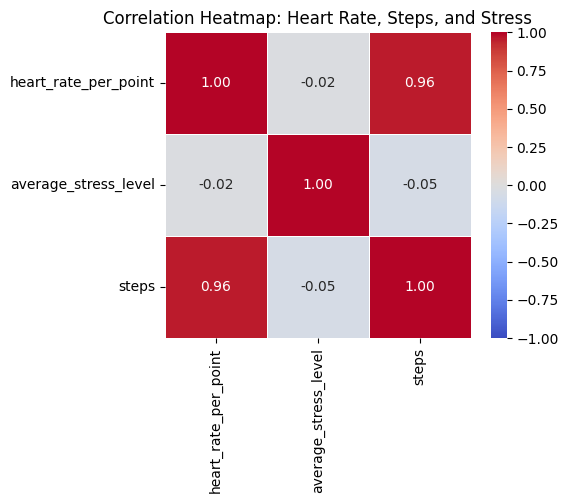

In [13]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap: Heart Rate, Steps, and Stress")
plt.tight_layout()
plt.show()


